# 02 — Clustering coffee sales

Unsupervised segmentation of `02_normalized.csv` with **K-Means**.

Coffee one-hot columns are mutually exclusive, so putting them in the distance would mostly recover drink types. This notebook clusters **purchase behavior** (`money`, `weekday`, `is_weekend`, `day_period`, `hour`, `cash_type`) and uses the coffee mix only to describe each group.

Output: `03_clustered.csv`

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CHOSEN_K = 3
BEHAVIOR_COLS = ["money", "weekday", "is_weekend", "day_period", "hour", "cash_type"]
CLUSTER_ORDER = ["Weekday morning", "Weekday evening", "Weekend"]
PALETTE = dict(zip(CLUSTER_ORDER, sns.color_palette("Set2", 3)))

df = pd.read_csv("02_normalized.csv")
coffee_cols = [c for c in df.columns if c.startswith("coffee_name_")]
df.head()

,money,weekday,is_weekend,day_period,hour,cash_type,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte
0,0.940585,4,0,1,10,0,0,0,0,0,0,0,0,1
1,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0
2,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0
3,0.492687,4,0,2,13,0,1,0,0,0,0,0,0,0
4,0.940585,4,0,2,13,0,0,0,0,0,0,0,0,1


## Choose k

K-Means needs comparable scales, so behavior features are standardized. Inertia (elbow), silhouette, and Davies–Bouldin are compared for \(k = 2 \ldots 10\).

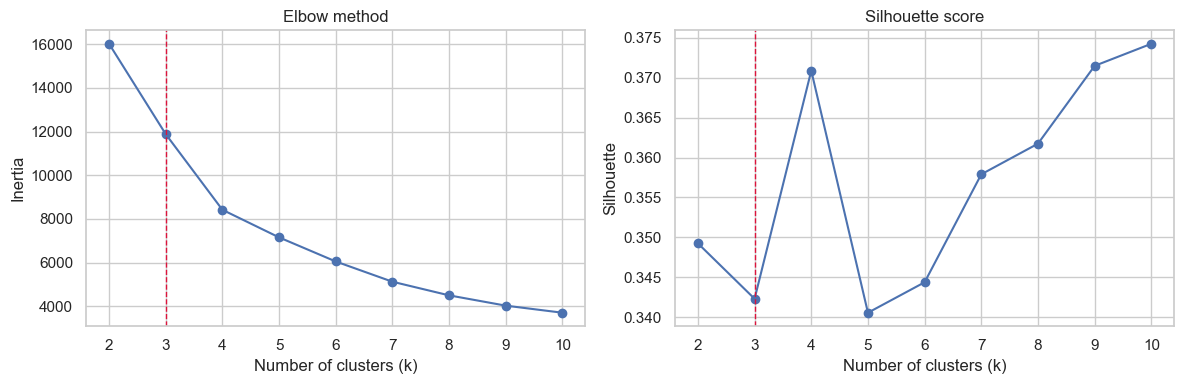

,k,inertia,silhouette,davies_bouldin
0,2,16014.539,0.349,1.248
1,3,11879.440,0.342,1.148
2,4,8417.505,0.371,0.921
3,5,7154.820,0.341,1.088
4,6,6052.131,0.344,1.099
5,7,5125.893,0.358,0.967
6,8,4501.951,0.362,0.980
7,9,4030.933,0.372,0.959
8,10,3707.239,0.374,0.956


In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(df[BEHAVIOR_COLS])

rows = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X)
    rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
        }
    )

metrics = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics["k"], metrics["inertia"], marker="o")
axes[0].axvline(CHOSEN_K, color="crimson", ls="--", lw=1)
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(metrics["k"], metrics["silhouette"], marker="o")
axes[1].axvline(CHOSEN_K, color="crimson", ls="--", lw=1)
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")
fig.tight_layout()
plt.show()

metrics.round(3)

**k = 3** is the cut used below. The elbow drops sharply from 2 → 3. Silhouette is similar for k = 2 and 3 (~0.34). k = 4 mostly isolates the 89 cash payments as their own tiny group, which is a payment method, not a purchase pattern.

In [11]:
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X)


def name_from_profile(group: pd.DataFrame) -> str:
    if group["is_weekend"].mean() >= 0.5:
        return "Weekend"
    if group["hour"].mean() < 14:
        return "Weekday morning"
    return "Weekday evening"


cluster_names = {cid: name_from_profile(g) for cid, g in df.groupby("cluster")}
df["cluster_name"] = df["cluster"].map(cluster_names)

summary = (
    df.groupby("cluster_name", sort=False)
    .agg(
        n=("cluster", "size"),
        money=("money", "mean"),
        hour=("hour", "mean"),
        weekday=("weekday", "mean"),
        is_weekend=("is_weekend", "mean"),
        cash_type=("cash_type", "mean"),
    )
    .reindex(CLUSTER_ORDER)
)
summary["share"] = summary["n"] / summary["n"].sum()
summary.round(3)

,n,money,hour,weekday,is_weekend,cash_type,share
cluster_name,,,,,,,
Weekday morning,1246,0.528,10.324,1.961,0.0,0.030,0.343
Weekday evening,1474,0.704,17.465,1.966,0.0,0.017,0.405
Weekend,916,0.621,14.085,5.474,1.0,0.029,0.252


## Visualizations

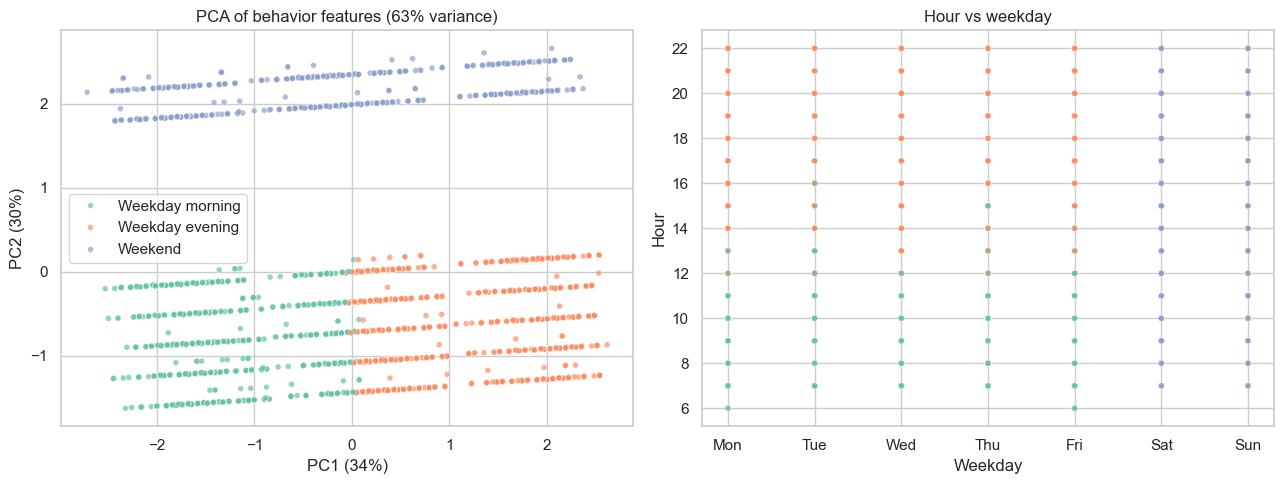

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
viz = pd.DataFrame(
    {
        "pc1": coords[:, 0],
        "pc2": coords[:, 1],
        "cluster_name": df["cluster_name"],
        "hour": df["hour"],
        "weekday": df["weekday"],
    }
)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    data=viz,
    x="pc1",
    y="pc2",
    hue="cluster_name",
    hue_order=CLUSTER_ORDER,
    palette=PALETTE,
    s=18,
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title(f"PCA of behavior features ({var.sum() * 100:.0f}% variance)")
axes[0].set_xlabel(f"PC1 ({var[0] * 100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({var[1] * 100:.0f}%)")
axes[0].legend(title="")

sns.scatterplot(
    data=viz,
    x="weekday",
    y="hour",
    hue="cluster_name",
    hue_order=CLUSTER_ORDER,
    palette=PALETTE,
    s=18,
    alpha=0.55,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Hour vs weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Hour")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
fig.tight_layout()
plt.show()

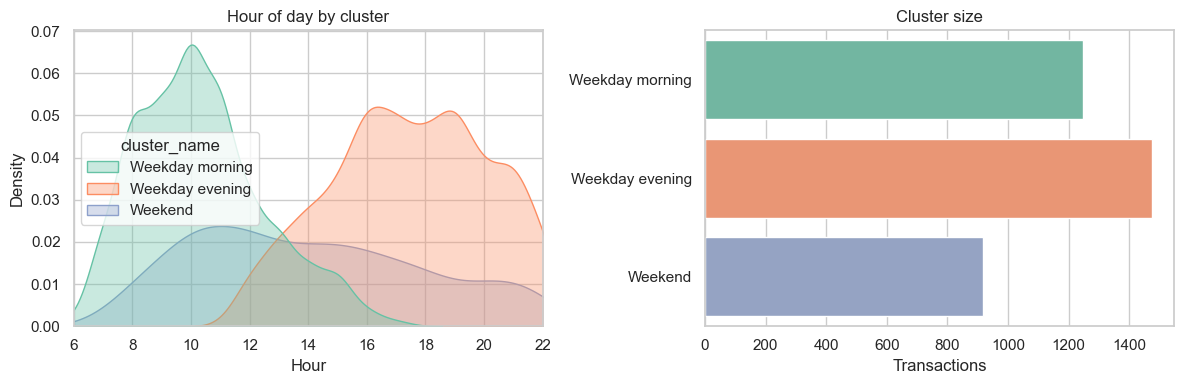

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(
    data=df,
    x="hour",
    hue="cluster_name",
    hue_order=CLUSTER_ORDER,
    palette=PALETTE,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Hour of day by cluster")
axes[0].set_xlabel("Hour")
axes[0].set_xlim(6, 22)

sns.countplot(
    data=df,
    y="cluster_name",
    order=CLUSTER_ORDER,
    hue="cluster_name",
    palette=PALETTE,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Cluster size")
axes[1].set_xlabel("Transactions")
axes[1].set_ylabel("")
fig.tight_layout()
plt.show()

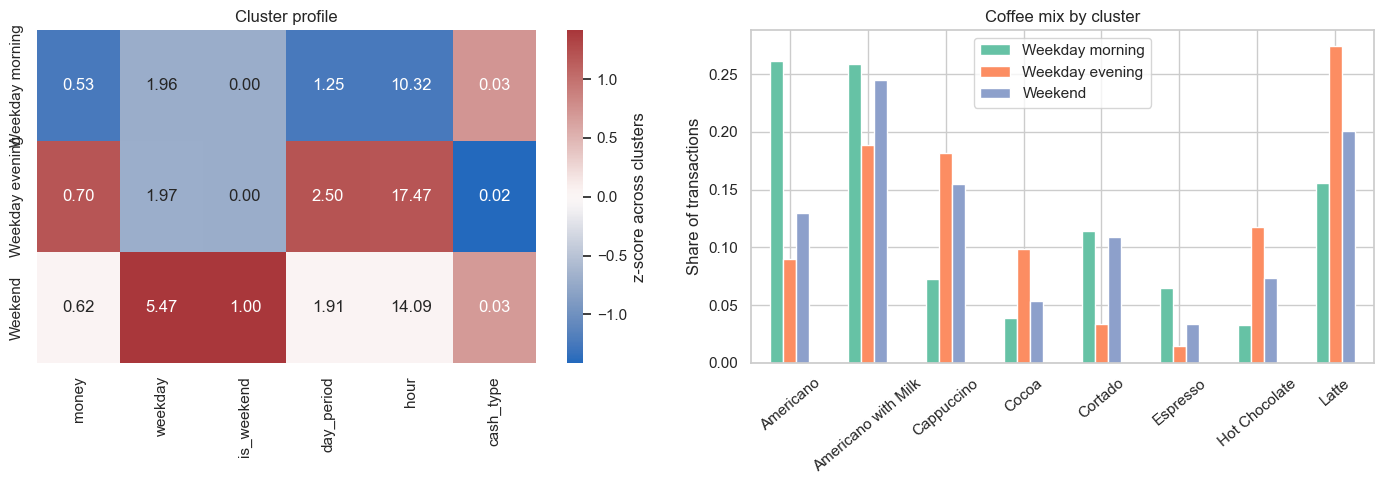

In [14]:
profile = df.groupby("cluster_name")[BEHAVIOR_COLS].mean().reindex(CLUSTER_ORDER)
profile_z = (profile - profile.mean()) / profile.std(ddof=0)

coffee_share = df.groupby("cluster_name")[coffee_cols].mean().reindex(CLUSTER_ORDER)
coffee_share.columns = [c.replace("coffee_name_", "") for c in coffee_share.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    profile_z,
    cmap="vlag",
    center=0,
    annot=profile.round(2),
    fmt=".2f",
    ax=axes[0],
    cbar_kws={"label": "z-score across clusters"},
)
axes[0].set_title("Cluster profile")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

coffee_share.T.plot(kind="bar", ax=axes[1], color=[PALETTE[n] for n in CLUSTER_ORDER])
axes[1].set_title("Coffee mix by cluster")
axes[1].set_ylabel("Share of transactions")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(title="")
fig.tight_layout()
plt.show()

## Groups

| Cluster | Pattern |
|---|---|
| **Weekday morning** | Weekdays, ~10h. Cheaper drinks: Americano and Americano with Milk. |
| **Weekday evening** | Weekdays, ~17h. Higher spend: Latte, Cappuccino, Hot Chocolate. |
| **Weekend** | Saturday/Sunday, mixed hours. Product mix in between the two weekday groups. |

In [15]:
out_path = Path("03_clustered.csv")
df.to_csv(out_path, index=False)
print(f"Wrote {out_path}  shape={df.shape}")
df.head()

Wrote 03_clustered.csv  shape=(3636, 16)


,money,weekday,is_weekend,day_period,hour,cash_type,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte,cluster,cluster_name
0,0.940585,4,0,1,10,0,0,0,0,0,0,0,0,1,2,Weekday morning
1,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0,0,Weekday evening
2,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0,0,Weekday evening
3,0.492687,4,0,2,13,0,1,0,0,0,0,0,0,0,2,Weekday morning
4,0.940585,4,0,2,13,0,0,0,0,0,0,0,0,1,0,Weekday evening


# 02 — Unsupervised clustering (GMM)

Source: `02_normalized.csv`

A **Gaussian Mixture Model** is an unsupervised ML model: it fits *n* Gaussians in feature space and assigns each transaction a probability of belonging to each group. The hard label is `argmax` of those probabilities.

Product one-hots (`coffee_name_*`) would make the model rediscover the 8 drinks, so clustering uses purchase context only:

`money`, `weekday`, `is_weekend`, `day_period`, `hour`, `cash_type`

Coffee type is kept for **interpretation** after the groups exist. Features are standardized before fitting (`StandardScaler`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

PALETTE = sns.color_palette("Set2")
RANDOM_STATE = 42

df = pd.read_csv("02_normalized.csv")
coffee_cols = [c for c in df.columns if c.startswith("coffee_name_")]
cluster_cols = [c for c in df.columns if c not in coffee_cols]

X = StandardScaler().fit_transform(df[cluster_cols])
print(df.shape)
print("cluster on:", cluster_cols)
df.head()

(3636, 14)
cluster on: ['money', 'weekday', 'is_weekend', 'day_period', 'hour', 'cash_type']


,money,weekday,is_weekend,day_period,hour,cash_type,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte
0,0.940585,4,0,1,10,0,0,0,0,0,0,0,0,1
1,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0
2,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0
3,0.492687,4,0,2,13,0,1,0,0,0,0,0,0,0
4,0.940585,4,0,2,13,0,0,0,0,0,0,0,0,1


## Choose the number of components

BIC and AIC fall as the mixture gets more components; silhouette measures how compact/separated the hard labels are. BIC often keeps dropping by isolating tiny groups (cash is only ~2% of rows). We pick a small *n* that already captures the main structure.

 n           bic           aic  silhouette                                            sizes
 2  -1823.124366  -2164.049536    0.594675                                       [89, 3547]
 3 -38900.897602 -39415.384677    0.371800                                  [62, 2658, 916]
 4 -52184.096143 -52872.145122    0.368430                              [27, 2658, 889, 62]
 5 -65981.053032 -66842.663916    0.363644                        [1754, 904, 612, 89, 277]
 6 -84452.363260 -85487.536049    0.343040                   [726, 904, 1028, 499, 89, 390]
 7 -86769.443000 -87978.177694    0.349363              [904, 726, 198, 89, 380, 1028, 311]
 8 -95150.273843 -96532.570442    0.351896           [1028, 277, 0, 89, 904, 414, 726, 198]
 9 -88163.757773 -89719.616276    0.265032      [363, 972, 612, 89, 56, 277, 331, 726, 210]
10 -94875.128309 -96604.548717    0.328511 [1028, 198, 387, 89, 726, 277, 0, 517, 244, 170]


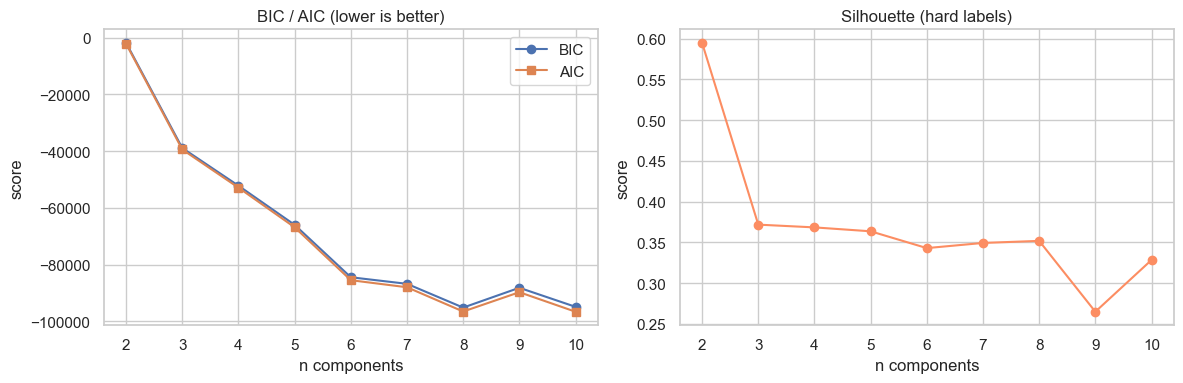

In [2]:
ns = range(2, 11)
bics, aics, silhouettes, sizes = [], [], [], []

for n in ns:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE, n_init=5)
    labels = gmm.fit_predict(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))
    silhouettes.append(silhouette_score(X, labels))
    sizes.append(np.bincount(labels, minlength=n).tolist())

metrics = pd.DataFrame({"n": list(ns), "bic": bics, "aic": aics, "silhouette": silhouettes, "sizes": sizes})
print(metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ns, bics, marker="o", label="BIC")
axes[0].plot(ns, aics, marker="s", label="AIC")
axes[0].set(title="BIC / AIC (lower is better)", xlabel="n components", ylabel="score")
axes[0].legend()
axes[1].plot(ns, silhouettes, marker="o", color=PALETTE[1])
axes[1].set(title="Silhouette (hard labels)", xlabel="n components", ylabel="score")
fig.tight_layout()
plt.show()

n = 3 is the useful cut: weekday (card), weekend, and a small cash group. From n = 4 onward BIC still falls, but mostly by splitting cash into weekday-cash vs weekend-cash.

In [3]:
N = 3
gmm = GaussianMixture(n_components=N, random_state=RANDOM_STATE, n_init=5)
df["cluster"] = gmm.fit_predict(X)
proba = gmm.predict_proba(X)
df["cluster_proba"] = proba.max(axis=1)

profile = df.groupby("cluster")[cluster_cols].mean()

def name_cluster(row):
    if row["cash_type"] > 0.5:
        return "Cash"
    if row["is_weekend"] > 0.5:
        return "Weekend"
    return "Weekday"

cluster_names = profile.apply(name_cluster, axis=1)
df["cluster_name"] = df["cluster"].map(cluster_names)

order = ["Weekday", "Weekend", "Cash"]
present = [n for n in order if n in df["cluster_name"].unique()]
colors = dict(zip(present, PALETTE[: len(present)]))

summary = (
    df.groupby("cluster_name")
    .agg(
        n=("cluster", "size"),
        money=("money", "mean"),
        hour=("hour", "mean"),
        weekend=("is_weekend", "mean"),
        cash=("cash_type", "mean"),
        proba=("cluster_proba", "mean"),
    )
    .reindex(present)
)
summary["share"] = summary["n"] / summary["n"].sum()
summary

,n,money,hour,weekend,cash,proba,share
cluster_name,,,,,,,
Weekday,2658,0.619238,14.209180,0.0,0.000000,1.0,0.731023
Weekend,916,0.620827,14.085153,1.0,0.029476,1.0,0.251925
Cash,62,0.804653,13.548387,0.0,1.000000,1.0,0.017052


## Views

PCA projects the 6-D mixture onto 2-D. The heatmap and bar charts describe each Gaussian after the hard assignment.

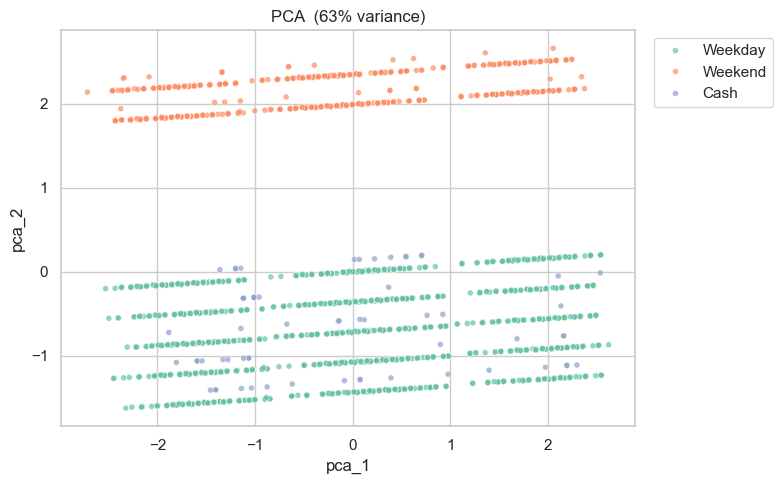

In [4]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca.fit_transform(X)
proj = df[["cluster_name"]].copy()
proj["pca_1"] = xy[:, 0]
proj["pca_2"] = xy[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=proj,
    x="pca_1",
    y="pca_2",
    hue="cluster_name",
    hue_order=present,
    palette=colors,
    s=18,
    alpha=0.7,
    ax=ax,
)
ax.set_title(f"PCA  ({pca.explained_variance_ratio_.sum():.0%} variance)")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

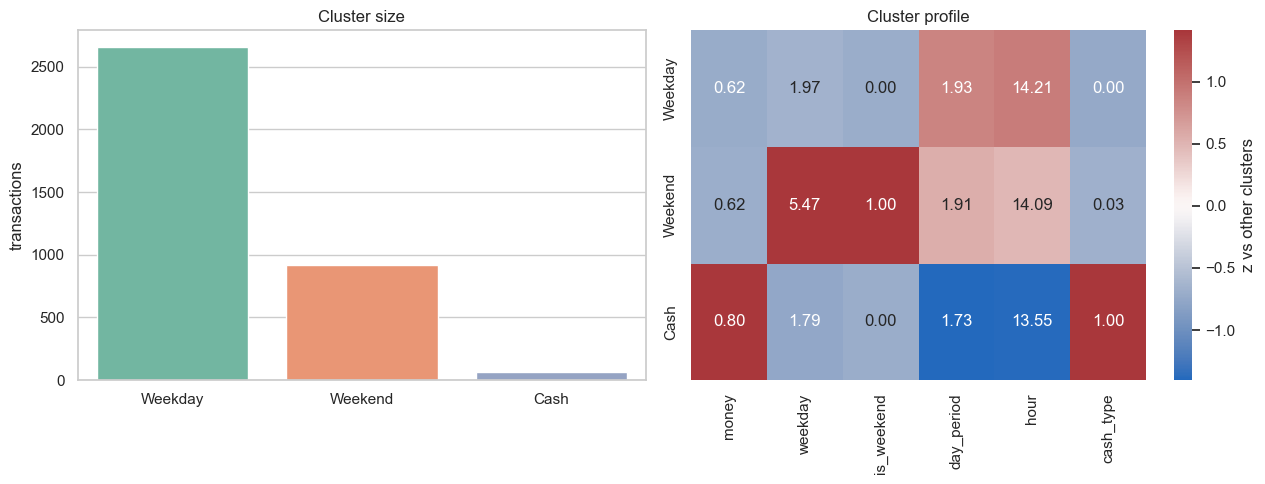

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["cluster_name"].value_counts().reindex(present)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=colors, legend=False, ax=axes[0])
axes[0].set(title="Cluster size", xlabel="", ylabel="transactions")

heat = df.groupby("cluster_name")[cluster_cols].mean().reindex(present)
heat_z = (heat - heat.mean()) / heat.std(ddof=0)
sns.heatmap(heat_z, cmap="vlag", center=0, annot=heat.round(2), fmt=".2f", ax=axes[1], cbar_kws={"label": "z vs other clusters"})
axes[1].set(title="Cluster profile", xlabel="", ylabel="")
fig.tight_layout()
plt.show()

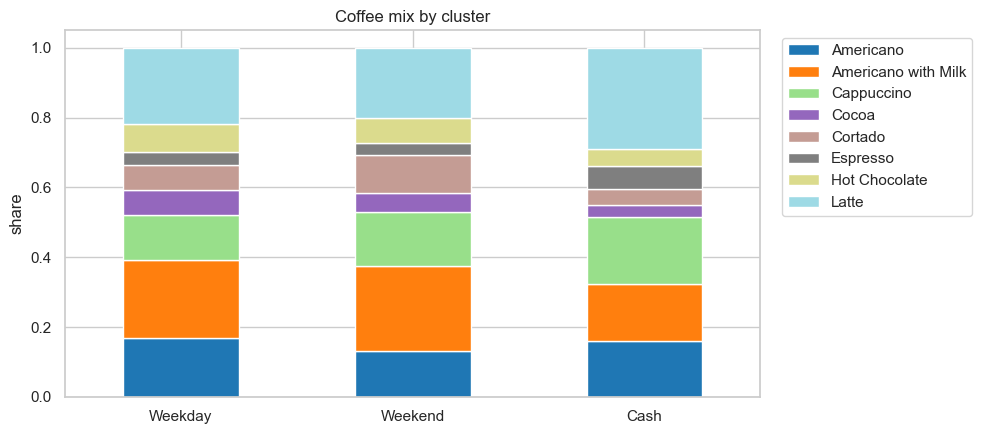

,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
cluster_name,,,,,,,,
Weekday,0.169,0.222,0.131,0.072,0.071,0.037,0.080,0.218
Weekend,0.130,0.245,0.155,0.053,0.109,0.034,0.073,0.201
Cash,0.161,0.161,0.194,0.032,0.048,0.065,0.048,0.290


In [6]:
coffee_share = (
    df.groupby("cluster_name")[coffee_cols]
    .mean()
    .reindex(present)
    .rename(columns=lambda c: c.replace("coffee_name_", ""))
)

fig, ax = plt.subplots(figsize=(10, 4.5))
coffee_share.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", rot=0)
ax.set(title="Coffee mix by cluster", xlabel="", ylabel="share")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()
coffee_share.round(3)

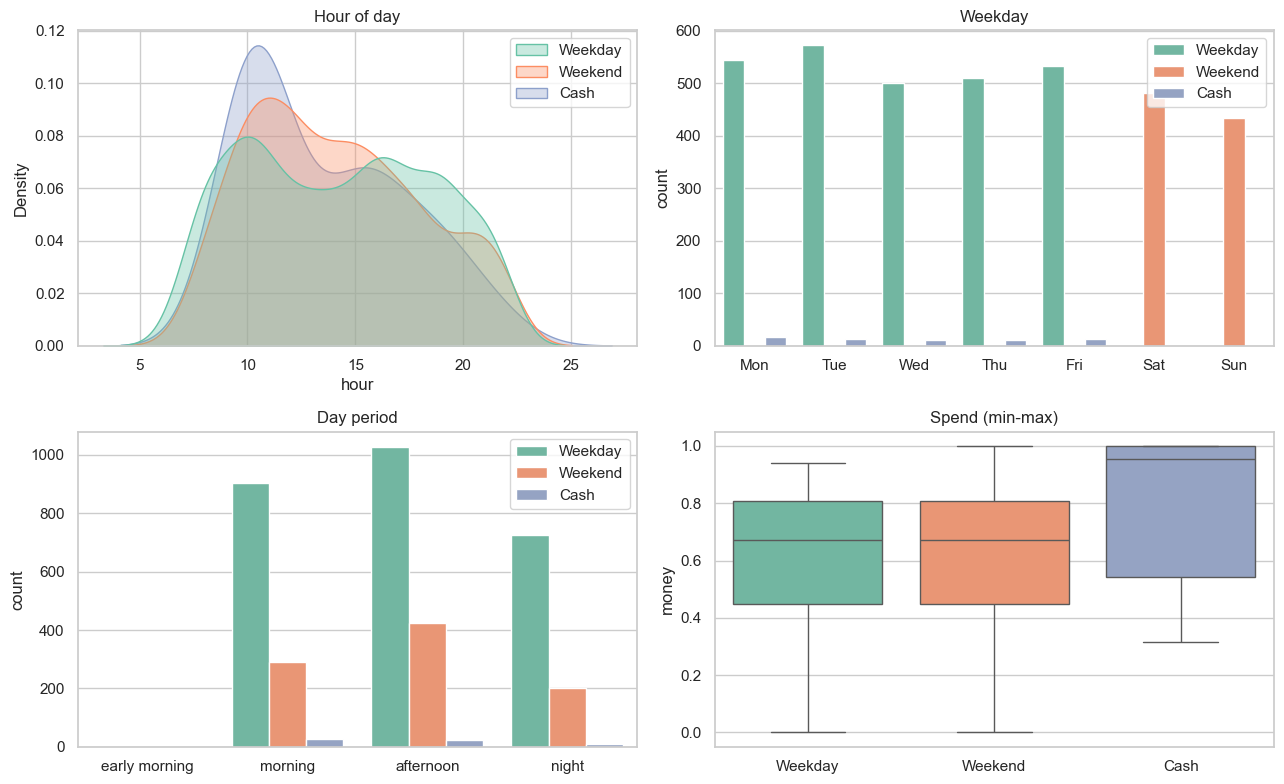

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.kdeplot(
    data=df,
    x="hour",
    hue="cluster_name",
    hue_order=present,
    palette=colors,
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Hour of day")
legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title("")

weekday_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
wd = df.assign(weekday_name=df["weekday"].map(weekday_map))
sns.countplot(
    data=wd,
    x="weekday_name",
    hue="cluster_name",
    hue_order=present,
    palette=colors,
    order=list(weekday_map.values()),
    ax=axes[0, 1],
)
axes[0, 1].set(title="Weekday", xlabel="")
legend = axes[0, 1].get_legend()
if legend is not None:
    legend.set_title("")

period_map = {0: "early morning", 1: "morning", 2: "afternoon", 3: "night"}
per = df.assign(period=df["day_period"].map(period_map))
sns.countplot(
    data=per,
    x="period",
    hue="cluster_name",
    hue_order=present,
    palette=colors,
    order=list(period_map.values()),
    ax=axes[1, 0],
)
axes[1, 0].set(title="Day period", xlabel="")
legend = axes[1, 0].get_legend()
if legend is not None:
    legend.set_title("")

sns.boxplot(
    data=df,
    x="cluster_name",
    y="money",
    hue="cluster_name",
    hue_order=present,
    palette=colors,
    order=present,
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set(title="Spend (min-max)", xlabel="")

fig.tight_layout()
plt.show()

## What the groups are

| Cluster | Pattern |
|---|---|
| **Weekday** | Monday–Friday, card, bulk of sales |
| **Weekend** | Saturday–Sunday |
| **Cash** | Small weekday cash group, slightly higher ticket |

GMM treats `cash_type` and `is_weekend` as strong separators (binary features with distinct Gaussians). Soft assignment is in `cluster_proba`.

In [8]:
out_path = Path("03_clustered.csv")
df.to_csv(out_path, index=False)
print(f"saved {out_path}  ({len(df)} rows)")
df["cluster_name"].value_counts().reindex(present)

saved 03_clustered.csv  (3636 rows)


cluster_name
Weekday    2658
Weekend     916
Cash         62
Name: count, dtype: int64